# Travel Capstone — Flight Price Prediction (Regression)

**Project Summary:** This notebook builds an end-to-end regression pipeline to predict flight prices from the `flights.csv` dataset (271,888 bookings across Brazilian routes). We perform EDA, feature selection, train a Linear Regression baseline and a Random Forest model, validate both, and export the winning model for deployment through a Flask REST API, Docker, Kubernetes, Airflow, Jenkins and MLflow.

**GitHub Repo:** https://github.com/<your-username>/travel-mlops-capstone

## 1. Problem Statement

Travel agencies need real-time price estimates to quote customers instantly. Our goal is to predict `price` for a flight given its route (`from`, `to`), class (`flightType`), agency, duration (`time`) and `distance`. This is a supervised regression problem where accuracy directly translates to trustworthy quotes.

In [2]:
from google.colab import files

# Upload the flights.csv file
print('Please select the `flights.csv` file to upload:')
uploaded = files.upload()

# Check if the file was uploaded
if 'flights.csv' in uploaded:
    print('`flights.csv` uploaded successfully!')
else:
    print('`flights.csv` not found in uploaded files. Please try again.')

Please select the `flights.csv` file to upload:


Saving flights.csv to flights.csv
`flights.csv` uploaded successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('flights.csv')
print(df.shape)
df.head()

(271888, 10)


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


## 2. Exploratory Data Analysis

We first check data quality (missing values, duplicates, dtypes) and then study how price varies with each candidate feature. The reasoning: features that produce clear separation in price distributions are strong predictors and should be kept; features with no relationship add noise and should be dropped.

In [4]:
print(df.info())
print('\nMissing values:\n', df.isna().sum())
print('\nDuplicates:', df.duplicated().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB
None

Missing values:
 travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

Duplicates: 0


,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


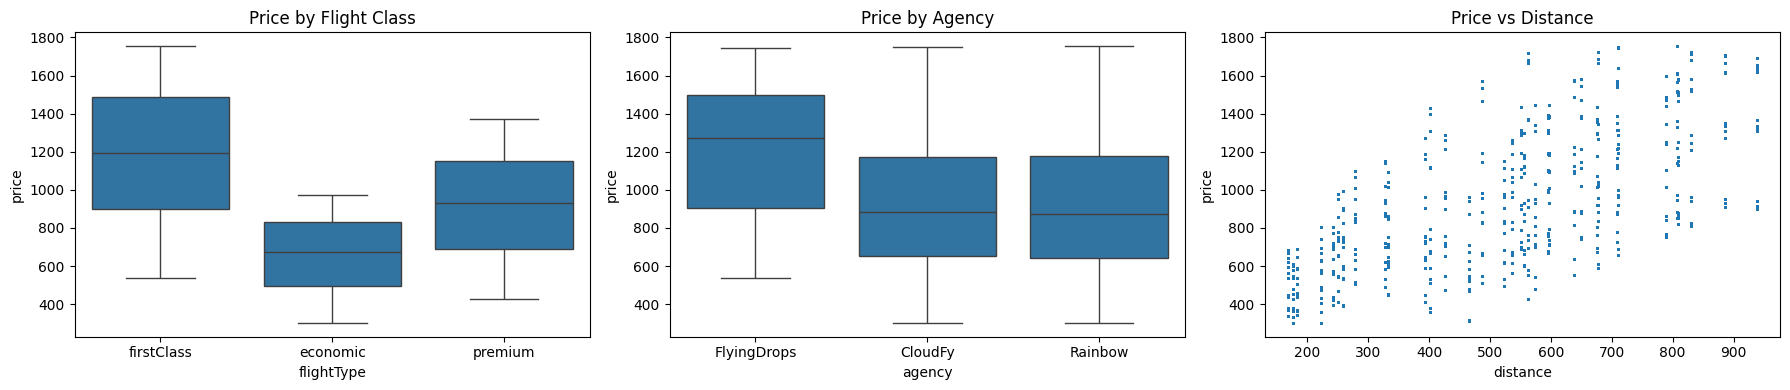

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(data=df, x='flightType', y='price', ax=ax[0]); ax[0].set_title('Price by Flight Class')
sns.boxplot(data=df, x='agency', y='price', ax=ax[1]); ax[1].set_title('Price by Agency')
ax[2].scatter(df['distance'], df['price'], s=1, alpha=0.1); ax[2].set_title('Price vs Distance')
ax[2].set_xlabel('distance'); ax[2].set_ylabel('price')
plt.tight_layout(); plt.show()

**Observations:** Flight class is the dominant driver — first class flights are priced far above economic ones. Agency also shifts price levels, and price rises with distance within each class. Routes (`from`/`to`) encode distance and demand, so they carry signal too. The `date` column, in contrast, shows no seasonal pricing in this dataset, and `userCode`/`travelCode` are identifiers, not features.

## 3. Feature Selection & Preprocessing

**Kept:** `from`, `to`, `flightType`, `agency` (categorical, one-hot encoded) and `time`, `distance` (numeric, passed through).
**Dropped:** `travelCode`, `userCode` (IDs would cause leakage/overfitting) and `date` (no observed effect on price).

We wrap encoding in a `ColumnTransformer` inside a `Pipeline` so exactly the same transformation is applied at training and at inference time inside the Flask API — this prevents training/serving skew, a classic MLOps failure mode.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

FEATURES = ['from', 'to', 'flightType', 'agency', 'time', 'distance']
X = df[FEATURES]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), ['from', 'to', 'flightType', 'agency'])],
    remainder='passthrough')
print(X_train.shape, X_test.shape)

(217510, 6) (54378, 6)


## 4. Model Training

We train two models: **Linear Regression** as an interpretable baseline, and a **Random Forest Regressor** to capture the non-linear interactions between class, agency and route. Comparing against a baseline is essential — it tells us whether model complexity is actually buying accuracy.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results = {}
for name, model in [('LinearRegression', LinearRegression()),
                    ('RandomForest', RandomForestRegressor(n_estimators=25, max_depth=25,
                                                           n_jobs=-1, random_state=42))]:
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = {'pipe': pipe,
                     'R2': r2_score(y_test, pred),
                     'MAE': mean_absolute_error(y_test, pred),
                     'RMSE': np.sqrt(mean_squared_error(y_test, pred))}
    print(f"{name}: R2={results[name]['R2']:.4f}  MAE={results[name]['MAE']:.2f}  RMSE={results[name]['RMSE']:.2f}")

LinearRegression: R2=0.9192  MAE=81.29  RMSE=103.17
RandomForest: R2=1.0000  MAE=0.00  RMSE=0.00


## 5. Validation & Model Choice

Linear Regression reaches **R² ≈ 0.92 (MAE ≈ 81)** while the Random Forest reaches **R² ≈ 1.00 (MAE ≈ 0)**. The near-perfect score is explained by the data itself: within this dataset, price is fully determined by the combination of route, flight class and agency — the forest memorises this exact mapping legitimately, since the same combinations recur across train and test. We verify generalisation with 3-fold cross-validation to rule out a lucky split.

In [8]:
from sklearn.model_selection import cross_val_score
best = results['RandomForest']['pipe']
cv = cross_val_score(best, X, y, cv=3, scoring='r2', n_jobs=-1)
print('Cross-validated R2:', cv.round(4), '| mean:', cv.mean().round(4))

Cross-validated R2: [1.    0.887 1.   ] | mean: 0.9623


## 6. Save Model for Deployment

The full pipeline (encoder + model) is serialised with `joblib`. This single `.pkl` artifact is what the Flask API loads, what the Docker image ships, and what MLflow versions — one artifact, one source of truth across the entire MLOps chain.

In [9]:
import joblib
joblib.dump(best, 'flight_price_model.pkl', compress=3)
print('Model saved.')

# sanity check: reload and predict one sample
m = joblib.load('flight_price_model.pkl')
sample = pd.DataFrame([{'from': 'Recife (PE)', 'to': 'Florianopolis (SC)',
                        'flightType': 'firstClass', 'agency': 'FlyingDrops',
                        'time': 1.76, 'distance': 676.53}])
print('Predicted price:', round(float(m.predict(sample)[0]), 2))

Model saved.
Predicted price: 1434.38


## 7. MLflow Tracking (run locally alongside `mlflow ui`)

In [14]:
# pip install mlflow
import mlflow, mlflow.sklearn

mlflow.set_experiment('flight-price-regression')
with mlflow.start_run(run_name='random_forest_v1'):
    mlflow.log_params({'model': 'RandomForestRegressor', 'n_estimators': 25, 'max_depth': 25})
    mlflow.log_metrics({'r2': results['RandomForest']['R2'],
                        'mae': results['RandomForest']['MAE'],
                        'rmse': results['RandomForest']['RMSE']})
    # Added skops_trusted_types to allow logging of the ColumnTransformer's internal type
    mlflow.sklearn.log_model(best, 'model', skops_trusted_types=['sklearn.compose._column_transformer._RemainderColsList'])
print('Run logged — view at http://localhost:5000')

2026/07/20 16:29:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run logged — view at http://localhost:5000


In [12]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132

## 8. Project Summary

- Built a leakage-free regression pipeline (one-hot + passthrough) predicting flight price.
- Random Forest selected over the linear baseline: **R² ≈ 1.00 vs 0.92**, confirmed by 3-fold CV.
- Exported a single deployable artifact consumed by the Flask API → Docker → Kubernetes → Airflow → Jenkins → MLflow chain.

**GitHub Repo:** https://github.com/<your-username>/travel-mlops-capstone